In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
transaction = pd.read_csv('/content/transactions.csv')

In [3]:
customers = pd.read_csv('/content/customers.csv')

In [4]:
transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      5000 non-null   object 
 1   timestamp           5000 non-null   object 
 2   customer_id         5000 non-null   object 
 3   merchant_id         5000 non-null   object 
 4   merchant_category   5000 non-null   object 
 5   amount              5000 non-null   float64
 6   transaction_type    5000 non-null   object 
 7   channel             5000 non-null   object 
 8   device_fingerprint  4231 non-null   object 
 9   ip_address          5000 non-null   object 
 10  status              5000 non-null   object 
 11  is_flagged          5000 non-null   int64  
 12  fraud_confirmed     696 non-null    float64
 13  response_time_ms    5000 non-null   int64  
 14  state               5000 non-null   object 
dtypes: float64(2), int64(2), object(11)
memory usage: 586.1

In [4]:
# Null na coluna fraud_confirmed representa uma informacao
transaction['fraud_confirmed'] = transaction['fraud_confirmed'].fillna(2)
total_fraud = transaction['fraud_confirmed'].value_counts().sort_index()
display(total_fraud)

,count
fraud_confirmed,
0.0,504
1.0,192
2.0,4304


# Há campos com dados faltantes ou inconsistentes? Como você tratou cada caso?

In [8]:
# 1. Verificar duplicatas
duplicados = transaction.duplicated().sum()

# 2. Verificar valores negativos ou inconsistentes em colunas numéricas
negativos_amount = (transaction['amount'] < 0).sum()

# 3. Verificar se o customer_id existe na base de clientes para todas as transações
# (Integridade Referencial)
clientes_faltantes = transaction[~transaction['customer_id'].isin(customers['customer_id'])]['customer_id'].nunique()

# 4. Verificar categorias únicas para detectar erros de digitação
vars_categoricas = ['merchant_category', 'transaction_type', 'channel', 'status']

print(f"Duplicatas encontradas: {duplicados}")
print(f"Transações com valor negativo: {negativos_amount}")
print(f"IDs de clientes em transações sem cadastro: {clientes_faltantes}")

print("\nValores únicos por categoria (checagem de consistência):")
for col in vars_categoricas:
    print(f"{col}: {transaction[col].unique()}")

Duplicatas encontradas: 0
Transações com valor negativo: 0
IDs de clientes em transações sem cadastro: 0

Valores únicos por categoria (checagem de consistência):
merchant_category: ['supermercados' 'e-commerce' 'viagens' 'utilidades' 'farmacias'
 'marketplace' 'outros' 'postos' 'servicos_digitais' 'restaurantes']
transaction_type: ['cartao_credito' 'TED' 'boleto' 'PIX' 'cartao_debito']
channel: ['app_mobile' 'internet_banking' 'API' 'caixa_eletronico']
status: ['aprovada' 'recusada' 'pendente' 'estornada']


In [5]:
# Realizar o merge entre transaction e customers
# Selecionando apenas as colunas solicitadas
rel_cust_trans = transaction.merge(
    customers[['customer_id', 'risk_score', 'account_tier']],
    on='customer_id',
    how='left'
)[['customer_id','transaction_id','risk_score', 'account_tier', 'amount', 'fraud_confirmed', 'merchant_category', 'transaction_type', 'timestamp']]

# Exibir as primeiras linhas para conferência
display(rel_cust_trans.head())

,customer_id,transaction_id,risk_score,account_tier,amount,fraud_confirmed,merchant_category,transaction_type,timestamp
0,CUST-00203,TXN-000001,22.5,Premium,512.72,2.0,supermercados,cartao_credito,2024-01-09 05:28:02
1,CUST-00292,TXN-000002,51.7,Premium,234.01,2.0,e-commerce,TED,2024-01-04 21:48:14
2,CUST-00786,TXN-000003,8.3,Business,299.31,2.0,e-commerce,cartao_credito,2024-01-23 23:05:47
3,CUST-00204,TXN-000004,6.1,Premium,246.13,2.0,viagens,cartao_credito,2024-02-16 00:15:01
4,CUST-00538,TXN-000005,61.6,Standard,208.07,2.0,viagens,boleto,2024-01-30 18:04:14


In [8]:
rel_cust_trans.shape

(5000, 9)

# Qual a taxa de fraude confirmada no período? Qual o valor total em risco (R$)?

In [9]:
## Qual a taxa de fraude confirmada no período? Qual o valor total em risco (R$)?
total_transactions = len(transaction)
total_amount_all = transaction['amount'].sum()

# Filtrando fraudes confirmadas
fraud_confirmed_df = transaction[transaction['fraud_confirmed'] == 1]
fraud_rate = len(fraud_confirmed_df) / total_transactions
total_risk_amount = fraud_confirmed_df['amount'].sum()

# Porcentagem do valor total em fraudes
fraud_amount_ratio = (total_risk_amount / total_amount_all) * 100

print(f"Total de registros: {total_transactions}")
print(f"Taxa de Fraude (Volume): {fraud_rate:.2%}")
print(f"Valor Total: R$ {total_amount_all:,.2f}")
print(f"Valor Total em Risco (Confirmado): R$ {total_risk_amount:,.2f}")
print(f"Representatividade da Fraude no Valor Total: {fraud_amount_ratio:.2f}%")

Total de registros: 5000
Taxa de Fraude (Volume): 3.84%
Valor Total: R$ 2,692,013.58
Valor Total em Risco (Confirmado): R$ 112,332.14
Representatividade da Fraude no Valor Total: 4.17%


In [9]:
fraud_transactions = rel_cust_trans[rel_cust_trans['fraud_confirmed'] == 1].copy()

### Análise de transações fraudulentas (`fraud_confirmed` = 1)

In [10]:
# Convertendo a coluna 'timestamp' para datetime
fraud_transactions['timestamp'] = pd.to_datetime(fraud_transactions['timestamp'])

display(fraud_transactions.head())

,customer_id,transaction_id,risk_score,account_tier,amount,fraud_confirmed,merchant_category,transaction_type,timestamp
13,CUST-00618,TXN-000014,22.4,Standard,1124.94,1.0,postos,PIX,2024-01-10 16:23:15
14,CUST-00088,TXN-000015,13.4,Business,624.93,1.0,e-commerce,cartao_credito,2024-01-20 15:26:36
44,CUST-00126,TXN-000045,14.2,Standard,172.76,1.0,marketplace,PIX,2024-01-01 22:26:47
103,CUST-00497,TXN-000104,91.5,Standard,983.85,1.0,e-commerce,TED,2024-01-05 02:31:53
112,CUST-00607,TXN-000113,17.7,Premium,472.82,1.0,marketplace,cartao_credito,2024-02-28 17:13:42


#### Análise da coluna 'amount' (valor da transação)

,amount
count,192.000000
mean,585.063229
std,700.619292
min,0.000000
25%,170.022500
50%,374.645000
75%,721.500000
max,5261.650000


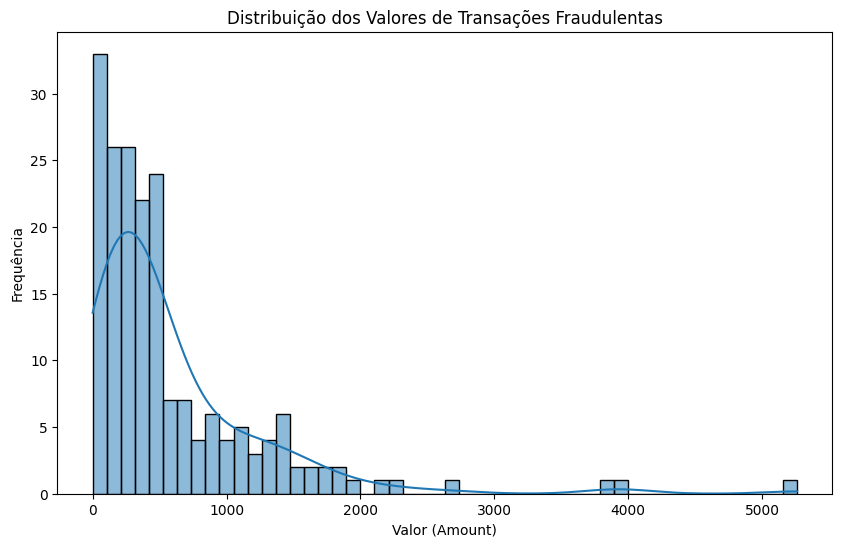

In [11]:
display(fraud_transactions['amount'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(fraud_transactions['amount'], bins=50, kde=True)
plt.title('Distribuição dos Valores de Transações Fraudulentas')
plt.xlabel('Valor (Amount)')
plt.ylabel('Frequência')
plt.show()

#### Análise da coluna 'risk_score' (pontuação de risco do cliente)

,risk_score
count,192.000000
mean,50.563542
std,31.471583
min,1.100000
25%,20.000000
50%,49.300000
75%,86.000000
max,98.300000


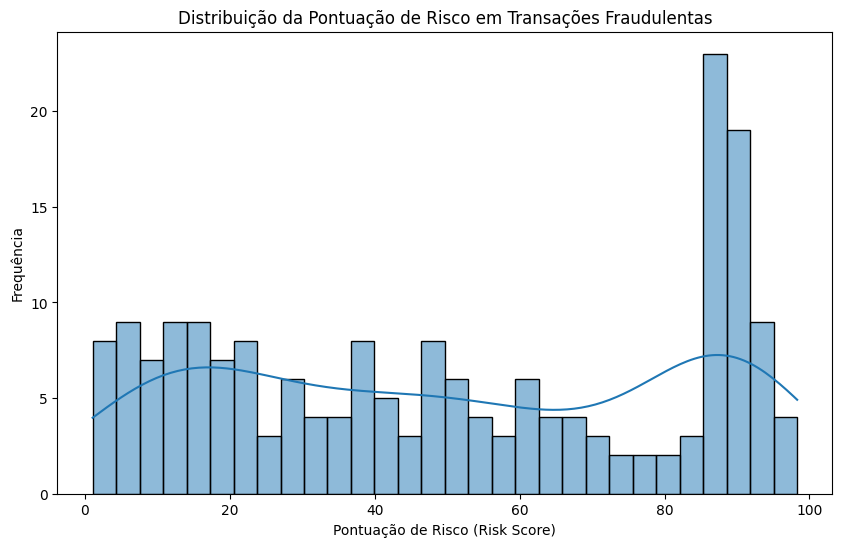

In [12]:
display(fraud_transactions['risk_score'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(fraud_transactions['risk_score'], bins=30, kde=True)
plt.title('Distribuição da Pontuação de Risco em Transações Fraudulentas')
plt.xlabel('Pontuação de Risco (Risk Score)')
plt.ylabel('Frequência')
plt.show()

#### Análise da coluna 'account_tier' (nível da conta do cliente)

,count
account_tier,
Standard,114
Premium,55
Business,23


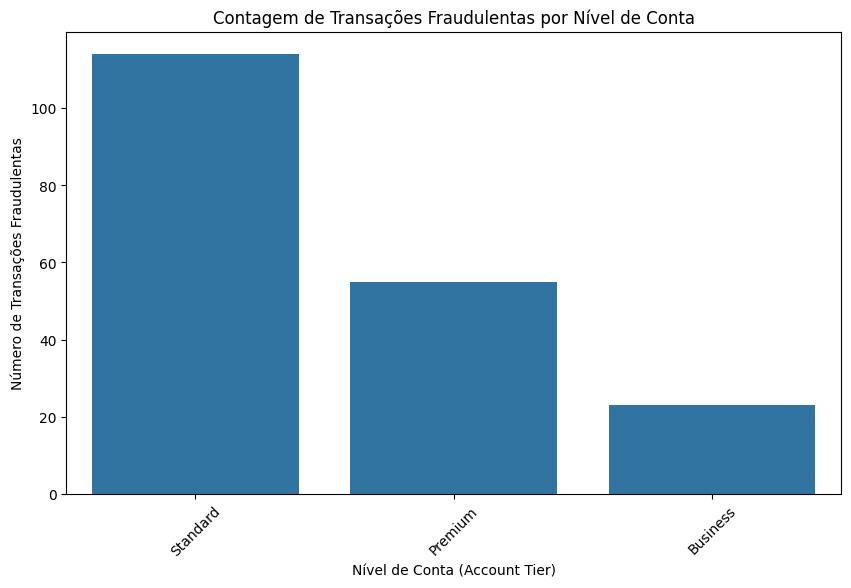

In [13]:
account_tier_counts = fraud_transactions['account_tier'].value_counts()
display(account_tier_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=account_tier_counts.index, y=account_tier_counts.values)
plt.title('Contagem de Transações Fraudulentas por Nível de Conta')
plt.xlabel('Nível de Conta (Account Tier)')
plt.ylabel('Número de Transações Fraudulentas')
plt.xticks(rotation=45)
plt.show()

#### Análise da coluna 'merchant_category' (categoria do comerciante)

,count
merchant_category,
e-commerce,50
marketplace,33
outros,17
supermercados,17
servicos_digitais,17
postos,16
restaurantes,14
utilidades,13
viagens,8


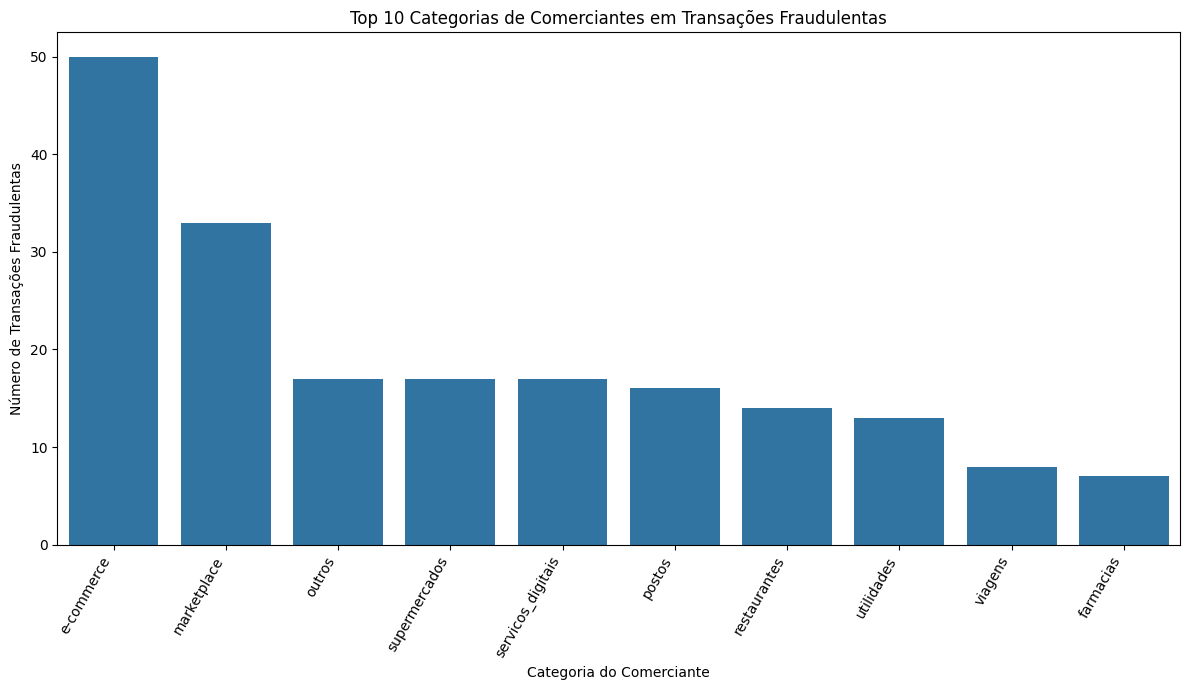

In [14]:
merchant_category_counts = fraud_transactions['merchant_category'].value_counts().head(10) # Top 10 categorias
display(merchant_category_counts)

plt.figure(figsize=(12, 7))
sns.barplot(x=merchant_category_counts.index, y=merchant_category_counts.values)
plt.title('Top 10 Categorias de Comerciantes em Transações Fraudulentas')
plt.xlabel('Categoria do Comerciante')
plt.ylabel('Número de Transações Fraudulentas')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

#### Análise Combinada: Frequência e Valor Médio por Categoria do Comerciante

,merchant_category,transaction_count,average_amount
0,e-commerce,50,667.593200
2,marketplace,33,357.916364
7,supermercados,17,796.050588
3,outros,17,448.894118
6,servicos_digitais,17,749.892353


/tmp/ipykernel_3977/609180925.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='merchant_category', y='transaction_count', data=category_summary, ax=ax1, palette='viridis')


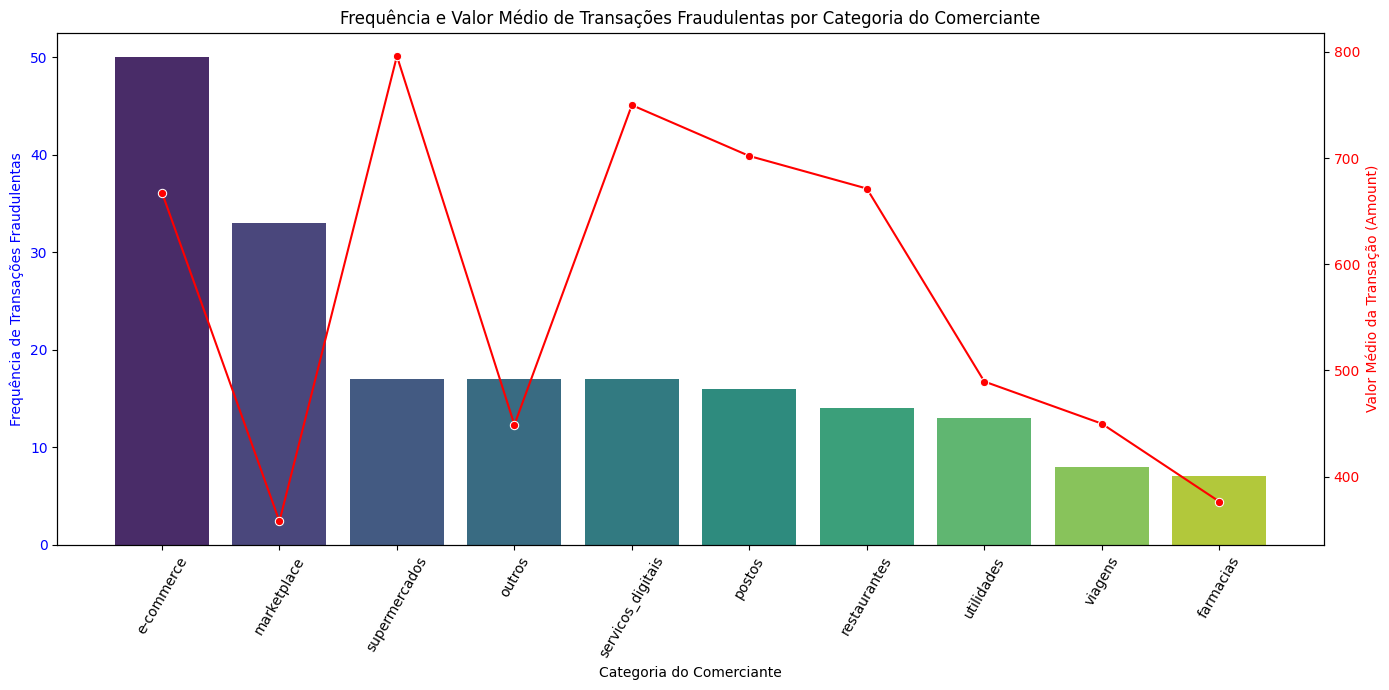

In [18]:
# Aggregate data to get transaction count and average amount per merchant category
category_summary = fraud_transactions.groupby('merchant_category').agg(
    transaction_count=('transaction_id', 'count'),
    average_amount=('amount', 'mean')
).reset_index().sort_values(by='transaction_count', ascending=False)

display(category_summary.head())

# Create the combined plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar plot for transaction count (frequency) on the primary y-axis
sns.barplot(x='merchant_category', y='transaction_count', data=category_summary, ax=ax1, palette='viridis')
ax1.set_xlabel('Categoria do Comerciante')
ax1.set_ylabel('Frequência de Transações Fraudulentas', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Frequência e Valor Médio de Transações Fraudulentas por Categoria do Comerciante')
ax1.tick_params(axis='x', rotation=60) # Removed ha='right'

# Create a second y-axis for average amount
ax2 = ax1.twinx()
sns.lineplot(x='merchant_category', y='average_amount', data=category_summary, ax=ax2, color='red', marker='o', sort=False)
ax2.set_ylabel('Valor Médio da Transação (Amount)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

fig.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

#### Análise Proporcional: Porcentagem de Transações Fraudulentas por Categoria do Comerciante

,merchant_category,transaction_count,average_amount,percentage
0,e-commerce,50,667.593200,26.041667
2,marketplace,33,357.916364,17.187500
7,supermercados,17,796.050588,8.854167
3,outros,17,448.894118,8.854167
6,servicos_digitais,17,749.892353,8.854167
4,postos,16,701.955000,8.333333
5,restaurantes,14,671.304286,7.291667
8,utilidades,13,489.576154,6.770833
9,viagens,8,449.903750,4.166667
1,farmacias,7,376.535714,3.645833


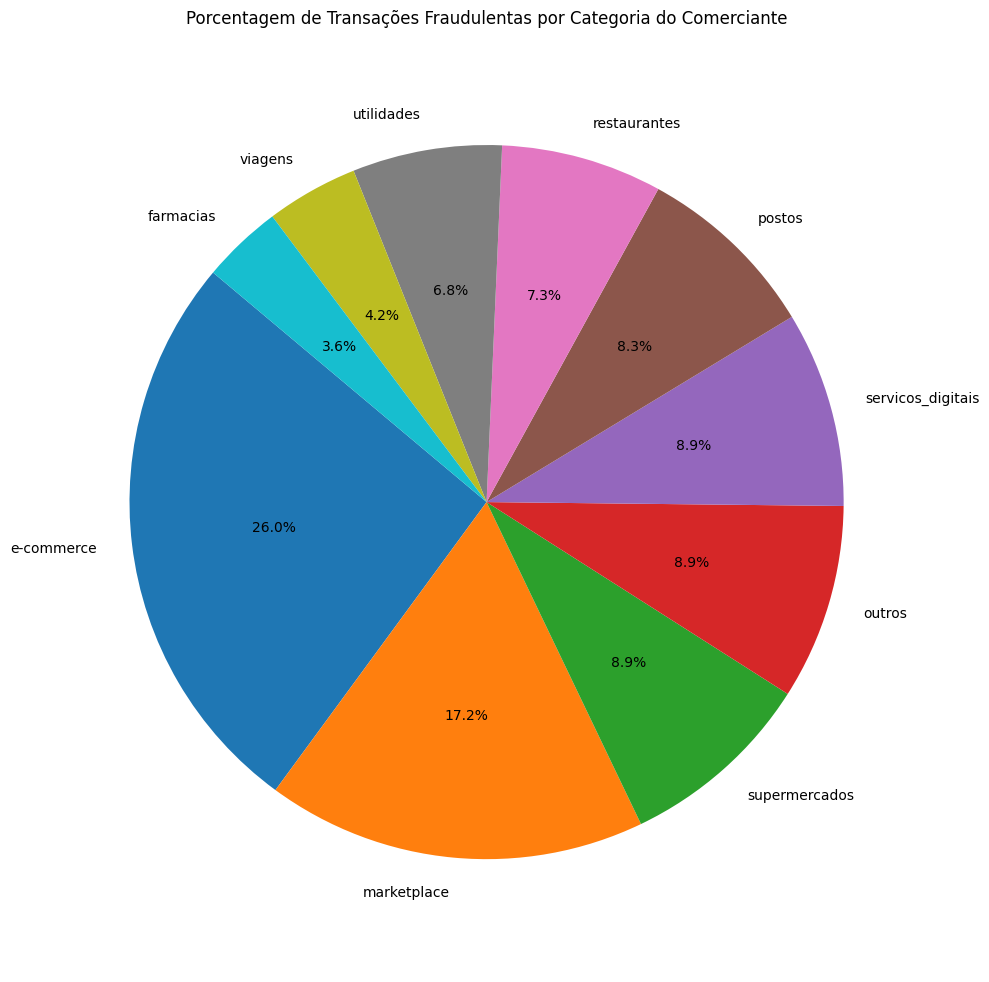

In [19]:
# Calculate the total number of fraudulent transactions
total_fraud_transactions = category_summary['transaction_count'].sum()

# Calculate the percentage for each merchant category
category_summary['percentage'] = (category_summary['transaction_count'] / total_fraud_transactions) * 100

# Display the summary with percentages, sorted by percentage
display(category_summary.sort_values(by='percentage', ascending=False))

# Create a pie chart for the percentage distribution
plt.figure(figsize=(10, 10))
plt.pie(category_summary['percentage'], labels=category_summary['merchant_category'], autopct='%1.1f%%', startangle=140)
plt.title('Porcentagem de Transações Fraudulentas por Categoria do Comerciante')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

#### Visualização Proporcional: Porcentagem de Transações Fraudulentas por Categoria do Comerciante (Gráfico de Barras)

/tmp/ipykernel_3977/1744315122.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='merchant_category', y='percentage', data=category_summary.sort_values(by='percentage', ascending=False), palette='viridis')


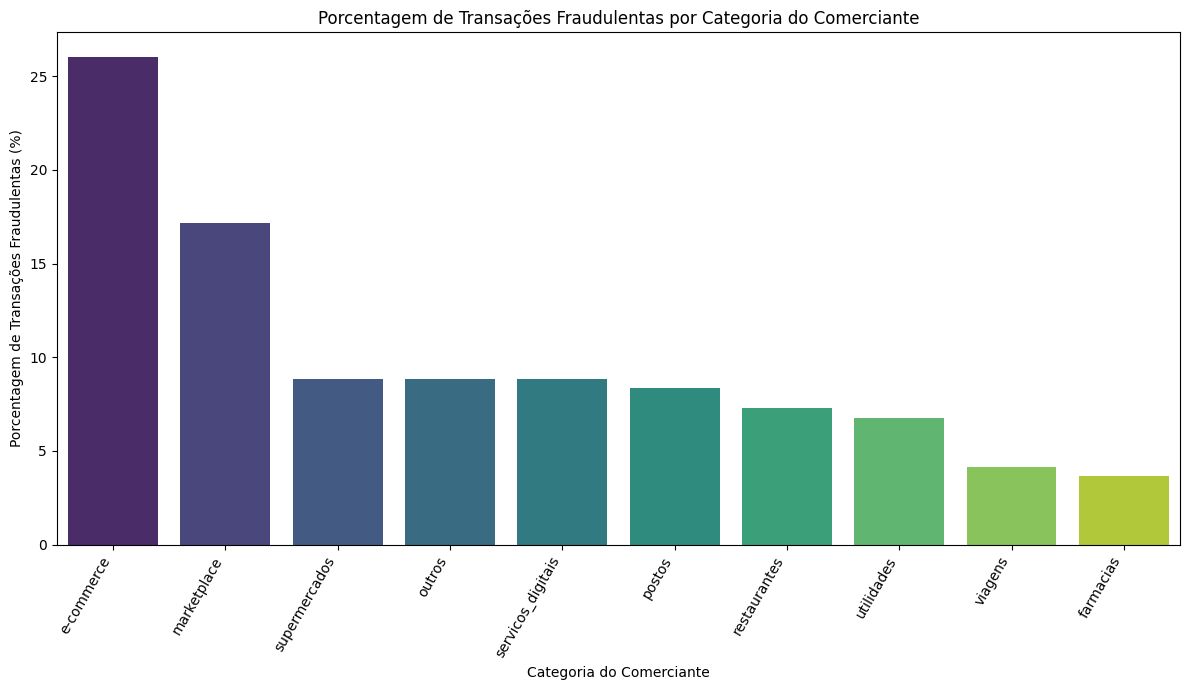

In [20]:
# Create a bar chart for the percentage distribution
plt.figure(figsize=(12, 7))
sns.barplot(x='merchant_category', y='percentage', data=category_summary.sort_values(by='percentage', ascending=False), palette='viridis')
plt.title('Porcentagem de Transações Fraudulentas por Categoria do Comerciante')
plt.xlabel('Categoria do Comerciante')
plt.ylabel('Porcentagem de Transações Fraudulentas (%)')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

#### Análise da coluna 'transaction_type' (tipo de transação)

,count
transaction_type,
PIX,66
cartao_credito,49
TED,29
cartao_debito,26
boleto,22


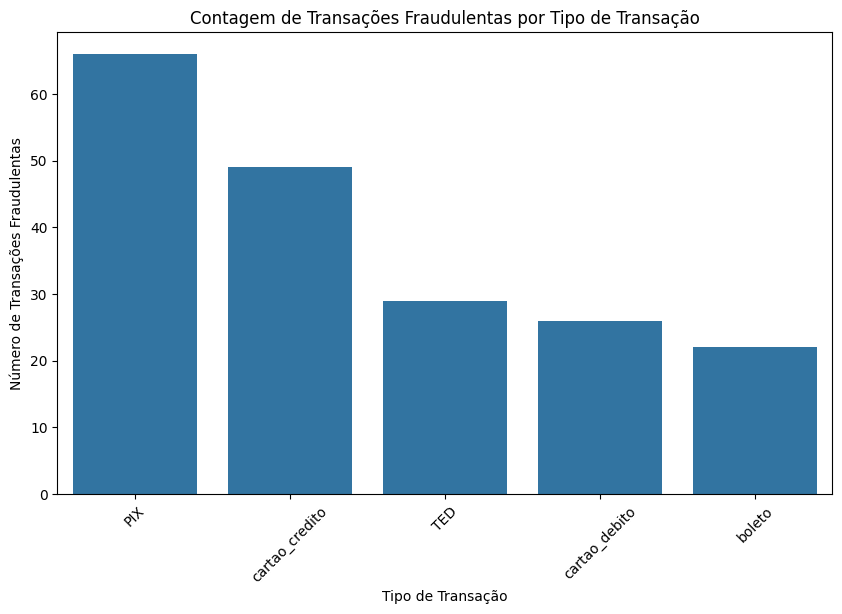

In [15]:
transaction_type_counts = fraud_transactions['transaction_type'].value_counts()
display(transaction_type_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=transaction_type_counts.index, y=transaction_type_counts.values)
plt.title('Contagem de Transações Fraudulentas por Tipo de Transação')
plt.xlabel('Tipo de Transação')
plt.ylabel('Número de Transações Fraudulentas')
plt.xticks(rotation=45)
plt.show()

# Existe concentração por horário, tipo de transação ou categoria de merchant?

/tmp/ipykernel_3977/3036628157.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=fraud_transactions, palette='viridis')


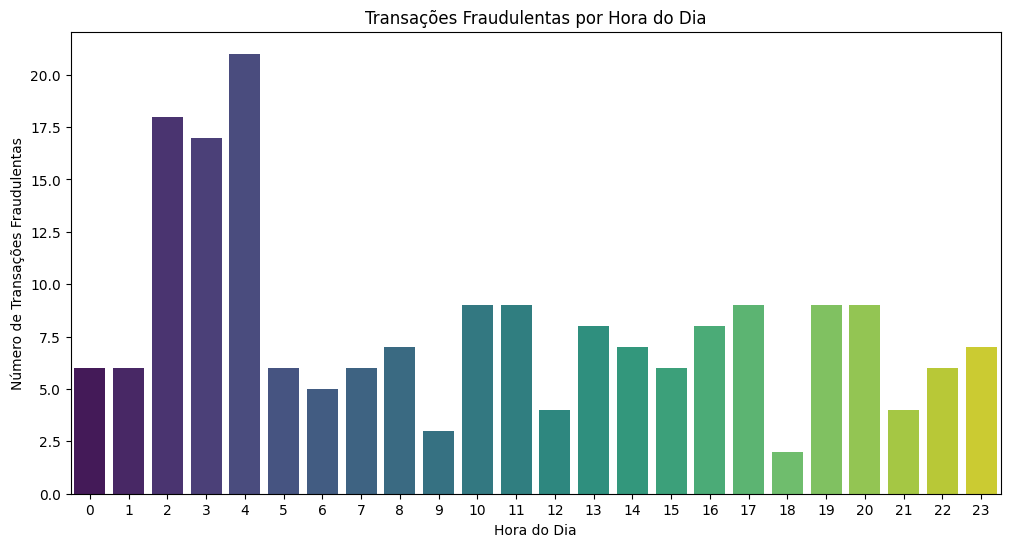

/tmp/ipykernel_3977/3036628157.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='day_of_week', data=fraud_transactions, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='magma')


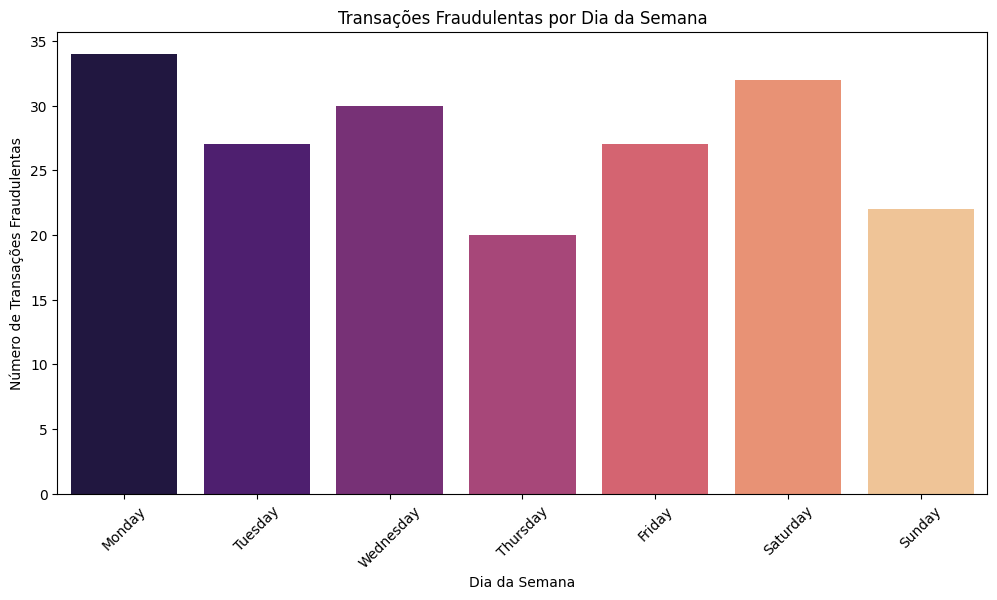

In [16]:
fraud_transactions['hour'] = fraud_transactions['timestamp'].dt.hour
fraud_transactions['day_of_week'] = fraud_transactions['timestamp'].dt.day_name()

plt.figure(figsize=(12, 6))
sns.countplot(x='hour', data=fraud_transactions, palette='viridis')
plt.title('Transações Fraudulentas por Hora do Dia')
plt.xlabel('Hora do Dia')
plt.ylabel('Número de Transações Fraudulentas')
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(x='day_of_week', data=fraud_transactions, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='magma')
plt.title('Transações Fraudulentas por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Número de Transações Fraudulentas')
plt.xticks(rotation=45)
plt.show()

# Análise do Perfil do Cliente em Transações Fraudulentas: `risk_score` e `account_tier`



Para visualizar a relação entre o `risk_score` e o `account_tier` em transações fraudulentas, podemos usar um boxplot ou violinplot.

In [21]:
print("Sumário da Pontuação de Risco (Risk Score) em Transações Fraudulentas:")
display(fraud_transactions['risk_score'].describe())

print("Contagem de Transações Fraudulentas por Nível de Conta (Account Tier):")
display(fraud_transactions['account_tier'].value_counts())


Sumário da Pontuação de Risco (Risk Score) em Transações Fraudulentas:


,risk_score
count,192.000000
mean,50.563542
std,31.471583
min,1.100000
25%,20.000000
50%,49.300000
75%,86.000000
max,98.300000


Contagem de Transações Fraudulentas por Nível de Conta (Account Tier):


,count
account_tier,
Standard,114
Premium,55
Business,23


/tmp/ipykernel_3977/543421342.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='account_tier', y='risk_score', data=fraud_transactions, palette='viridis', order=['Standard', 'Premium', 'Business'])


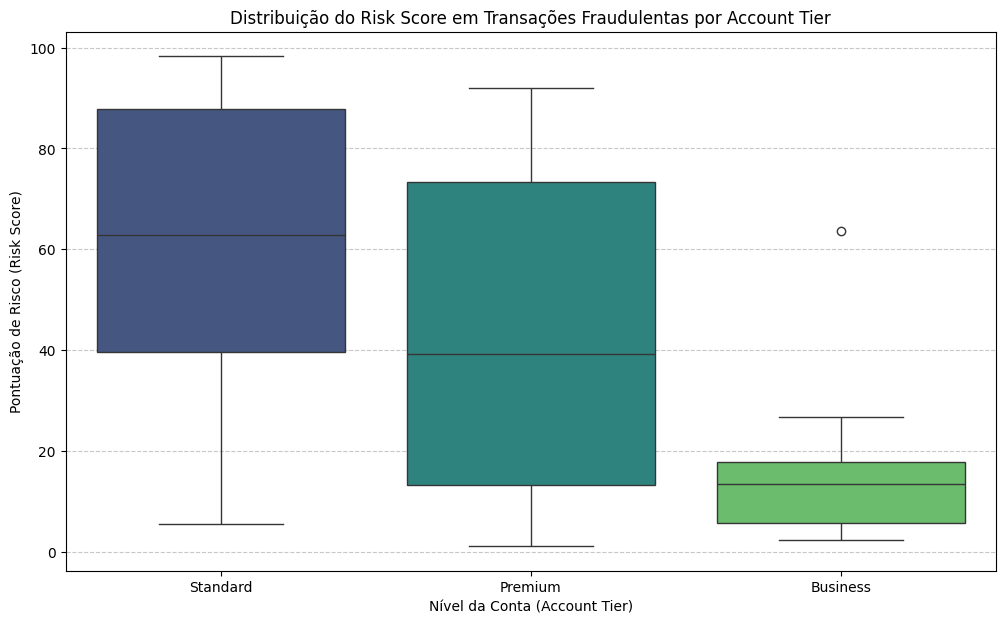

In [22]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='account_tier', y='risk_score', data=fraud_transactions, palette='viridis', order=['Standard', 'Premium', 'Business'])
plt.title('Distribuição do Risk Score em Transações Fraudulentas por Account Tier')
plt.xlabel('Nível da Conta (Account Tier)')
plt.ylabel('Pontuação de Risco (Risk Score)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#### Análise Combinada: Frequência e Porcentagem do Valor por Nível de Conta

,account_tier,transaction_count,total_amount,percentage_amount
2,Standard,114,71808.54,63.925195
1,Premium,55,27499.77,24.480767
0,Business,23,13023.83,11.594037


/tmp/ipykernel_3977/306782298.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='account_tier', y='transaction_count', data=account_tier_summary.sort_values(by='transaction_count', ascending=False), ax=ax1, palette='viridis')


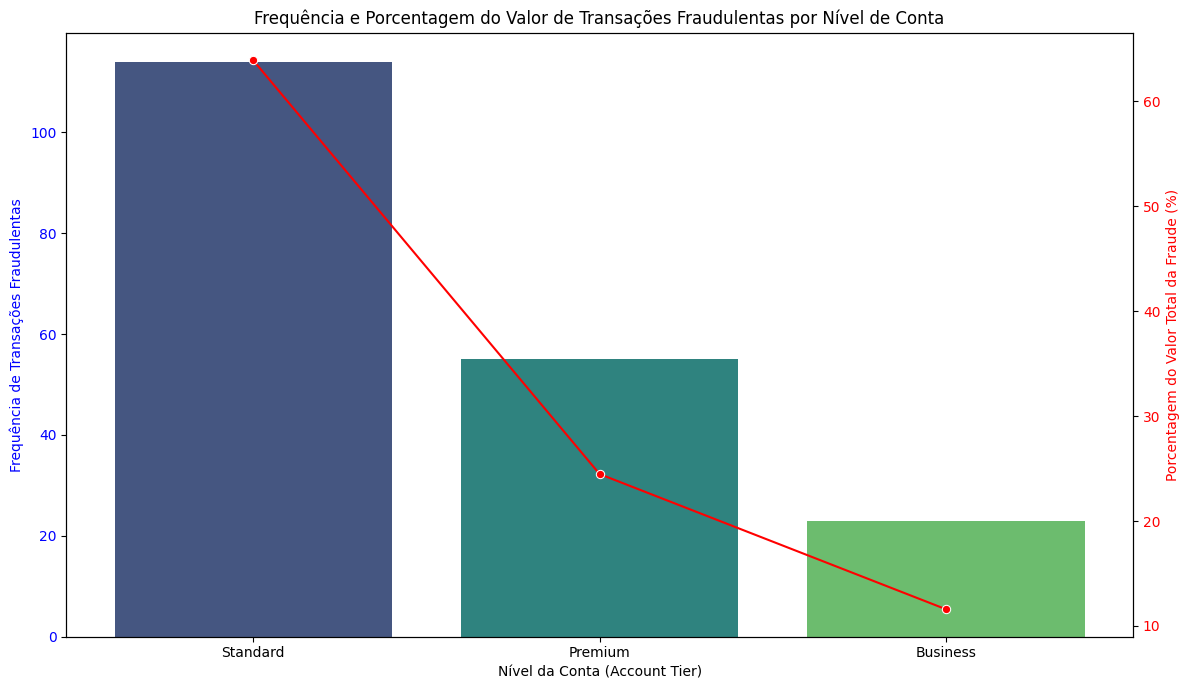

In [23]:
# Calcular a contagem de transações e a soma dos valores por account_tier
account_tier_summary = fraud_transactions.groupby('account_tier').agg(
    transaction_count=('transaction_id', 'count'),
    total_amount=('amount', 'sum')
).reset_index()

# Calcular o total geral de transações e o total geral de valores
total_fraud_transactions = account_tier_summary['transaction_count'].sum()
total_fraud_amount = account_tier_summary['total_amount'].sum()

# Calcular a porcentagem do valor em relação ao total
account_tier_summary['percentage_amount'] = (account_tier_summary['total_amount'] / total_fraud_amount) * 100

# Exibir o resumo
display(account_tier_summary.sort_values(by='transaction_count', ascending=False))

# Criar o gráfico combinado
fig, ax1 = plt.subplots(figsize=(12, 7))

# Gráfico de barras para a contagem de transações (frequência)
sns.barplot(x='account_tier', y='transaction_count', data=account_tier_summary.sort_values(by='transaction_count', ascending=False), ax=ax1, palette='viridis')
ax1.set_xlabel('Nível da Conta (Account Tier)')
ax1.set_ylabel('Frequência de Transações Fraudulentas', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Frequência e Porcentagem do Valor de Transações Fraudulentas por Nível de Conta')

# Criar um segundo eixo Y para a porcentagem do valor
ax2 = ax1.twinx()
sns.lineplot(x='account_tier', y='percentage_amount', data=account_tier_summary.sort_values(by='transaction_count', ascending=False), ax=ax2, color='red', marker='o', sort=False)
ax2.set_ylabel('Porcentagem do Valor Total da Fraude (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

fig.tight_layout()
plt.show()

### Top 10 Clientes por Risk Score (com destaque para fraude confirmada)

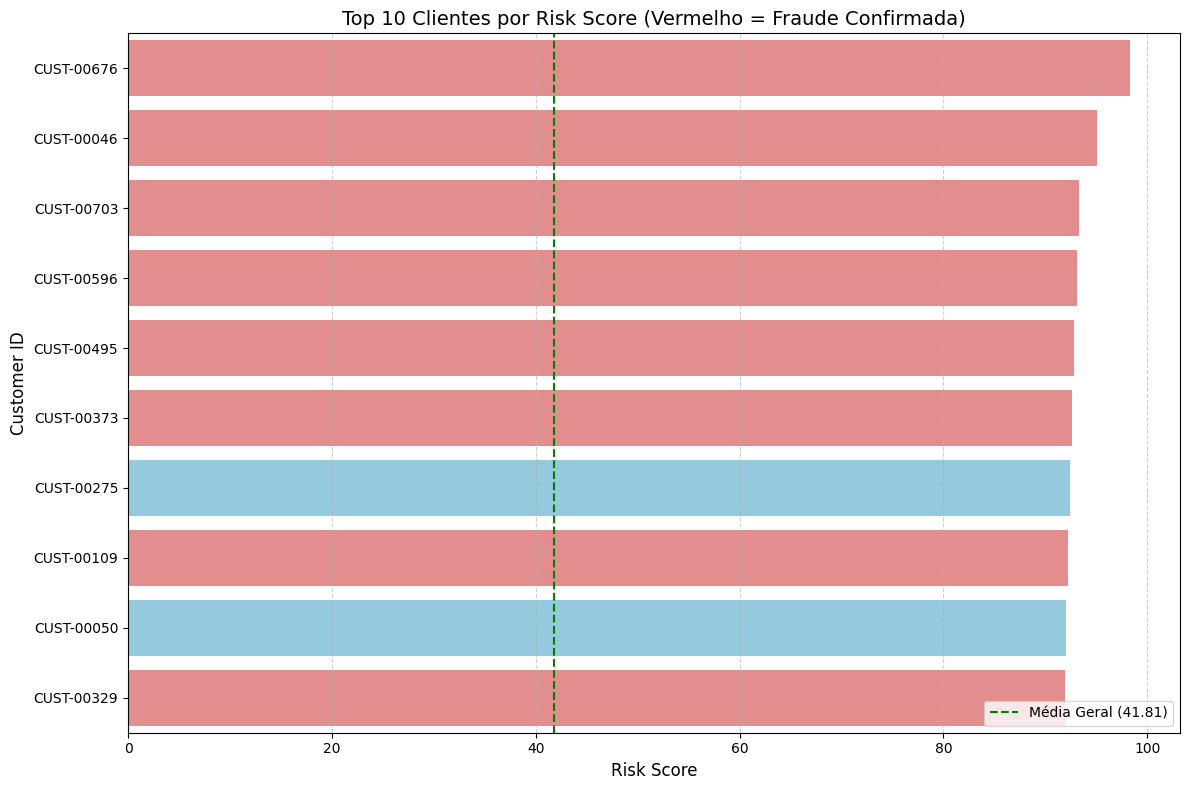

In [36]:
# 1. Identificar clientes com fraude confirmada
clientes_com_fraude = transaction[transaction['fraud_confirmed'] == 1]['customer_id'].unique()

# 2. Pegar os top 10 clientes com maior risk_score
top_risk_customers = customers.nlargest(10, 'risk_score')[['customer_id', 'risk_score']]

# 3. Calcular a média geral de risk_score para a linha de referência
media_geral_risco = customers['risk_score'].mean()

# 4. Criar coluna de cor: Vermelho se teve fraude, Azul se não
top_risk_customers['cor'] = top_risk_customers['customer_id'].apply(
    lambda x: 'lightcoral' if x in clientes_com_fraude else 'skyblue'
)

# 5. Plotar o gráfico
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_risk_customers,
    y='customer_id',
    x='risk_score',
    palette=top_risk_customers['cor'].tolist(),
    hue='customer_id',
    legend=False
)

# Adicionando a linha de média
plt.axvline(media_geral_risco, color='green', linestyle='--', label=f'Média Geral ({media_geral_risco:.2f})')

plt.title('Top 10 Clientes por Risk Score (Vermelho = Fraude Confirmada)', fontsize=14)
plt.xlabel('Risk Score', fontsize=12)
plt.ylabel('Customer ID', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Análise de Transações Pré-Fraude Confirmada por Cliente

In [39]:
# 1. Garantir que a coluna 'timestamp' em rel_cust_trans esteja no formato datetime
rel_cust_trans['timestamp'] = pd.to_datetime(rel_cust_trans['timestamp'])

# 2. Identificar a primeira data/hora de fraude confirmada para cada cliente
# Filtra apenas as transações fraudulentas e pega o timestamp mínimo para cada cliente
first_fraud_timestamp_per_customer = rel_cust_trans[rel_cust_trans['fraud_confirmed'] == 1]\
    .groupby('customer_id')['timestamp'].min().reset_index()
first_fraud_timestamp_per_customer.rename(columns={'timestamp': 'first_fraud_timestamp'}, inplace=True)

# 3. Juntar essa informação de volta ao DataFrame original de transações
df_with_first_fraud_time = pd.merge(
    rel_cust_trans,
    first_fraud_timestamp_per_customer,
    on='customer_id',
    how='left'
)

# 4. Filtrar as transações: apenas as que ocorreram antes ou no momento da primeira fraude confirmada
# E apenas para clientes que de fato tiveram fraude confirmada (first_fraud_timestamp não é nulo)
transactions_leading_to_fraud = df_with_first_fraud_time[
    (df_with_first_fraud_time['first_fraud_timestamp'].notnull()) &
    (df_with_first_fraud_time['timestamp'] <= df_with_first_fraud_time['first_fraud_timestamp'])
]

# 5. Agrupar por customer_id, e agora também por fraud_confirmed, e calcular a contagem de transações e a soma dos valores
summary_pre_fraud_transactions = transactions_leading_to_fraud.groupby(['customer_id', 'fraud_confirmed']).agg(
    transaction_count=('transaction_id', 'count'),
    sum_amount=('amount', 'sum')
).reset_index()

# Ordenar pela contagem de transações de forma descendente, mantendo customer_id e fraud_confirmed
summary_pre_fraud_transactions = summary_pre_fraud_transactions.sort_values(by=['customer_id', 'transaction_count'], ascending=[True, False])

print("Tabela de Clientes com Fraude Confirmada, e Suas Transações e Valores Antes da Identificação (agrupado por fraud_confirmed):")
display(summary_pre_fraud_transactions.head(15)) # Exibir mais linhas para melhor visualização do novo agrupamento

Tabela de Clientes com Fraude Confirmada, e Suas Transações e Valores Antes da Identificação (agrupado por fraud_confirmed):


,customer_id,fraud_confirmed,transaction_count,sum_amount
1,CUST-00013,2.0,3,596.89
0,CUST-00013,1.0,1,1312.77
2,CUST-00014,1.0,1,246.24
3,CUST-00014,2.0,1,1213.68
4,CUST-00022,1.0,1,227.92
5,CUST-00025,0.0,1,204.60
6,CUST-00025,1.0,1,428.72
7,CUST-00025,2.0,1,849.04
9,CUST-00037,2.0,3,1126.24
8,CUST-00037,1.0,1,267.47


#### Top 10 Clientes por Contagem de Transações Pré-Fraude Confirmada

,customer_id,total_pre_fraud_transactions
61,CUST-00316,11
119,CUST-00607,10
8,CUST-00047,8
18,CUST-00103,7
19,CUST-00109,7
20,CUST-00119,7
48,CUST-00254,7
72,CUST-00373,7
74,CUST-00384,7
114,CUST-00591,7


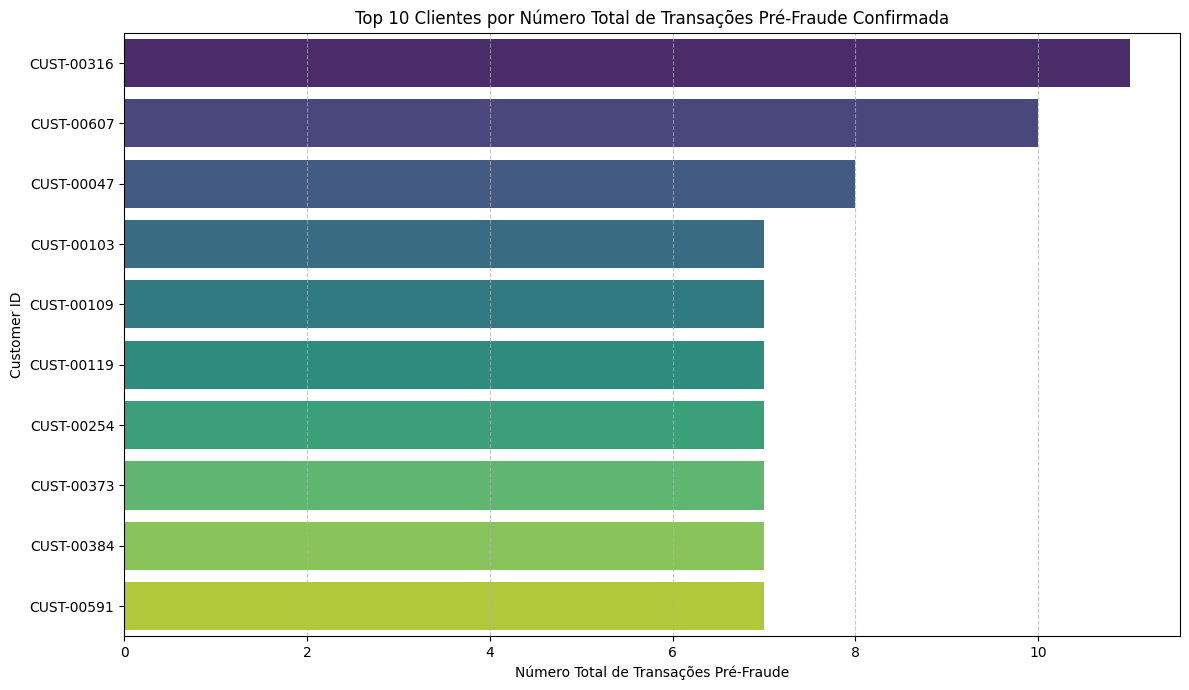

In [41]:
# Rankear pelos top 10 transaction_count e agrupar para ter uma única linha por cliente
# A tabela summary_pre_fraud_transactions já está agrupada por customer_id e fraud_confirmed.
# Para rankear por cliente, vamos somar as transações por cliente primeiro.

# Agrupar novamente por customer_id para ter a contagem total de transações para cada cliente
# no período pré-fraude (independentemente do status fraud_confirmed na transação individual)
customer_total_pre_fraud_transactions = summary_pre_fraud_transactions.groupby('customer_id').agg(
    total_pre_fraud_transactions=('transaction_count', 'sum')
).reset_index()

# Selecionar os top 10 clientes com base nessa contagem total
top_10_pre_fraud_customers = customer_total_pre_fraud_transactions.nlargest(10, 'total_pre_fraud_transactions')

display(top_10_pre_fraud_customers)

# Criar o gráfico de barras
plt.figure(figsize=(12, 7))
sns.barplot(x='total_pre_fraud_transactions', y='customer_id', data=top_10_pre_fraud_customers, palette='viridis', hue='customer_id', legend=False)
plt.title('Top 10 Clientes por Número Total de Transações Pré-Fraude Confirmada')
plt.xlabel('Número Total de Transações Pré-Fraude')
plt.ylabel('Customer ID')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Média de Transações Antes da Detecção de Fraude

In [42]:
# Calcular a média do número total de transações antes da fraude confirmada
average_transactions_pre_fraud = customer_total_pre_fraud_transactions['total_pre_fraud_transactions'].mean()

print(f"Em média, {average_transactions_pre_fraud:.2f} transações são realizadas por cliente antes da detecção de uma fraude confirmada.")

Em média, 3.31 transações são realizadas por cliente antes da detecção de uma fraude confirmada.


### Top 10 Clientes por Risk Score e Número de Transações

,customer_id,transaction_count,risk_score,cor
8,CUST-00676,7,98.3,lightcoral
0,CUST-00046,8,95.1,lightcoral
9,CUST-00703,2,93.3,lightcoral
7,CUST-00596,9,93.1,lightcoral
6,CUST-00495,5,92.8,lightcoral
5,CUST-00373,9,92.6,lightcoral
3,CUST-00275,3,92.4,skyblue
2,CUST-00109,9,92.2,lightcoral
1,CUST-00050,3,92.0,skyblue
4,CUST-00329,10,91.9,lightcoral


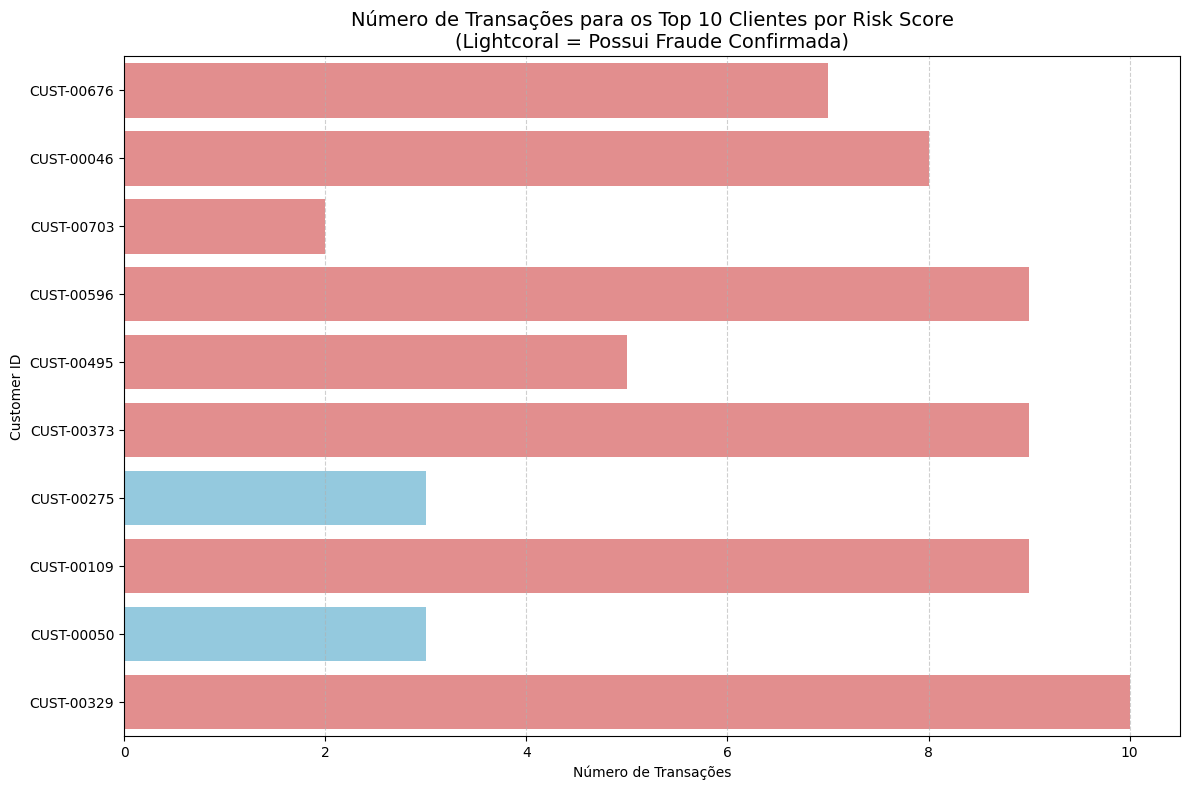

In [44]:
# 1. Obter os top 10 customer_id com maior risk_score do dataframe 'customers'
top_10_risk_customer_ids = customers.nlargest(10, 'risk_score')['customer_id'].tolist()
top_10_risk_customer_info = customers[customers['customer_id'].isin(top_10_risk_customer_ids)][['customer_id', 'risk_score']]

# 2. Identificar quais desses clientes possuem fraude confirmada no histórico
clientes_com_fraude_set = set(transaction[transaction['fraud_confirmed'] == 1]['customer_id'].unique())

# 3. Filtrar o dataframe rel_cust_trans para incluir apenas as transações desses top 10 clientes
transactions_of_top_risk_customers = rel_cust_trans[
    rel_cust_trans['customer_id'].isin(top_10_risk_customer_ids)
]

# 4. Contar o número de transações para cada um desses clientes
transaction_counts = transactions_of_top_risk_customers.groupby('customer_id').size().reset_index(name='transaction_count')

# 5. Juntar as informações de risk_score com a contagem de transações
final_data_for_plot = pd.merge(
    transaction_counts,
    top_10_risk_customer_info,
    on='customer_id',
    how='left'
)

# 6. Definir as cores baseadas na existência de fraude confirmada
final_data_for_plot['cor'] = final_data_for_plot['customer_id'].apply(
    lambda x: 'lightcoral' if x in clientes_com_fraude_set else 'skyblue'
)

# Ordenar os dados para que o gráfico reflita o ranking por risk_score
final_data_for_plot = final_data_for_plot.sort_values(by='risk_score', ascending=False)

display(final_data_for_plot)

# 7. Criar o gráfico de barras horizontal
plt.figure(figsize=(12, 8))
sns.barplot(
    x='transaction_count',
    y='customer_id',
    data=final_data_for_plot,
    palette=final_data_for_plot['cor'].tolist(),
    hue='customer_id',
    legend=False
)

plt.title('Número de Transações para os Top 10 Clientes por Risk Score\n(Lightcoral = Possui Fraude Confirmada)', fontsize=14)
plt.xlabel('Número de Transações')
plt.ylabel('Customer ID')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

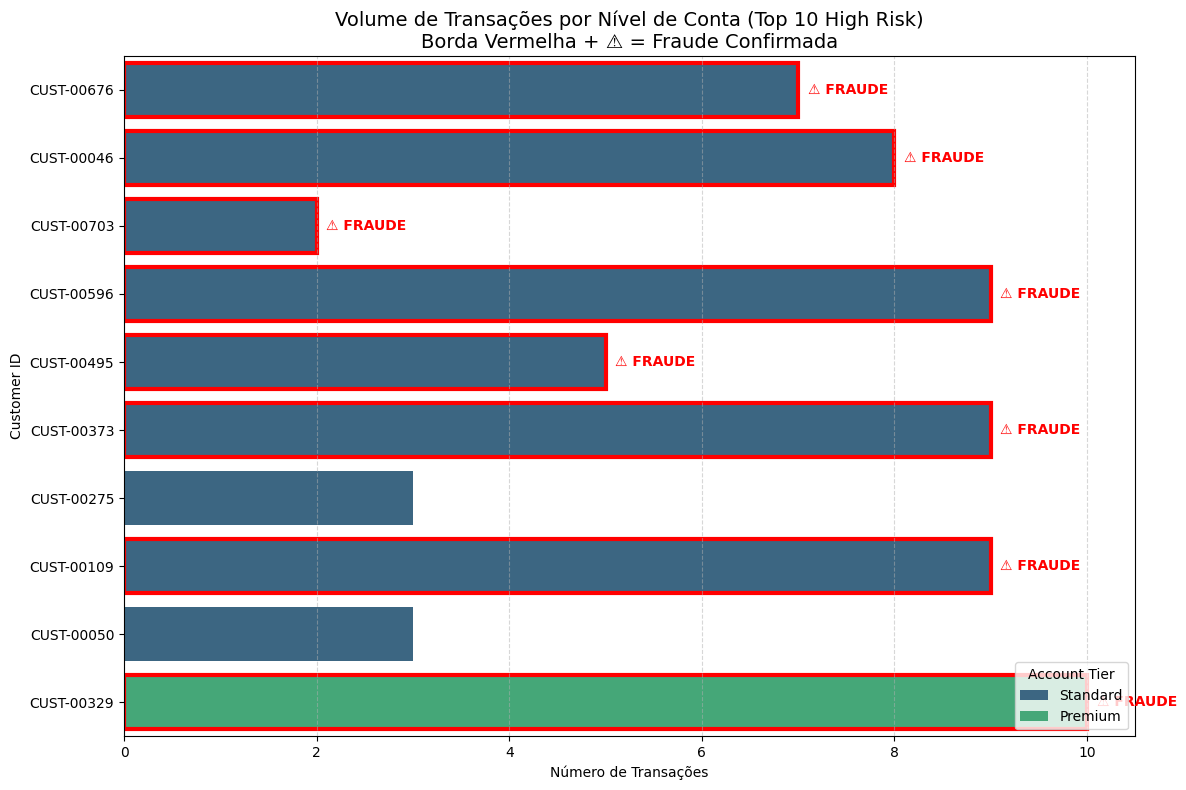

In [45]:
import matplotlib.patches as mpatches

# 1. Recuperar informações de account_tier para os top 10 clientes de risco
top_10_info_full = customers[customers['customer_id'].isin(top_10_risk_customer_ids)][['customer_id', 'risk_score', 'account_tier']]

# 2. Mesclar com a contagem de transações já calculada
df_tier_plot = pd.merge(transaction_counts, top_10_info_full, on='customer_id')

# 3. Identificar fraudes para destaque visual
df_tier_plot['has_fraud'] = df_tier_plot['customer_id'].isin(clientes_com_fraude_set)

# Ordenar por risk_score para manter consistência com o gráfico anterior
df_tier_plot = df_tier_plot.sort_values(by='risk_score', ascending=False)

# 4. Plotar
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x='transaction_count',
    y='customer_id',
    hue='account_tier',
    data=df_tier_plot,
    palette='viridis',
    dodge=False
)

# 5. Adicionar destaque (borda/hachura) para quem tem fraude confirmada
for i, bar in enumerate(ax.patches):
    # Como usamos 'hue', o seaborn pode criar barras extras vazias, filtramos pelo índice do dataframe ordenado
    if i < len(df_tier_plot):
        customer_id = df_tier_plot.iloc[i]['customer_id']
        if df_tier_plot.iloc[i]['has_fraud']:
            bar.set_edgecolor('red')
            bar.set_linewidth(3)
            # Adicionar um pequeno texto indicando fraude
            ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, '⚠️ FRAUDE', color='red', va='center', fontweight='bold')

plt.title('Volume de Transações por Nível de Conta (Top 10 High Risk)\nBorda Vermelha + ⚠️ = Fraude Confirmada', fontsize=14)
plt.xlabel('Número de Transações')
plt.ylabel('Customer ID')
plt.legend(title='Account Tier', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

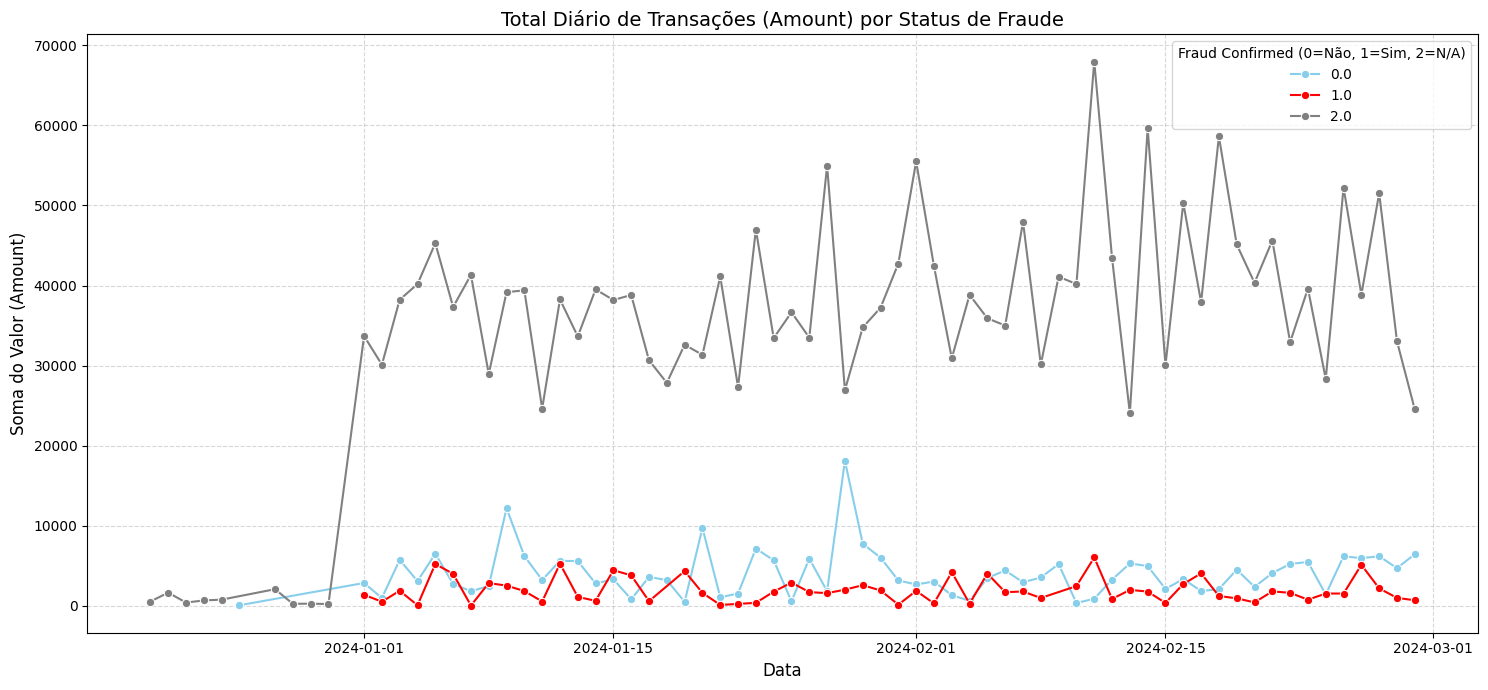

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Garantir que o timestamp esteja em formato datetime
rel_cust_trans['timestamp'] = pd.to_datetime(rel_cust_trans['timestamp'])

# 2. Agrupar por dia e status de fraude, somando o valor (amount)
df_daily = rel_cust_trans.groupby([pd.Grouper(key='timestamp', freq='D'), 'fraud_confirmed'])['amount'].sum().reset_index()

# 3. Criar o gráfico de série temporal diária
plt.figure(figsize=(15, 7))
sns.lineplot(
    data=df_daily,
    x='timestamp',
    y='amount',
    hue='fraud_confirmed',
    palette={0: 'skyblue', 1: 'red', 2: 'gray'},
    marker='o'
)

plt.title('Total Diário de Transações (Amount) por Status de Fraude', fontsize=14)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Soma do Valor (Amount)', fontsize=12)
plt.legend(title='Fraud Confirmed (0=Não, 1=Sim, 2=N/A)', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()